# 03 - Statistical Analysis

Goal: validate with statistical tests which variables are associated with churn, and decide which ones should not enter the model due to leakage risk.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

sns.set_style("whitegrid")

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
MONTHLY_CHARGE_COL = "Monthly_Charge"
INTERNET_DEPENDENT_COLS = [
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
]

df = pd.read_csv(DATA_PATH)
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

# Filter out negative Monthly_Charge (see 02_eda.ipynb) in both sets: Monthly_Charge
# enters the model as a raw numeric feature, so a Joined customer with this dirty
# value would be scored with an out-of-range input if it isn't filtered the same
# way as in training.
df_model = df_model.loc[df_model[MONTHLY_CHARGE_COL] >= 0].copy()
df_joined = df_joined.loc[df_joined[MONTHLY_CHARGE_COL] >= 0].copy()

# Impute structural missing values (see 02_eda.ipynb): these NaN are not missing at
# random, they exist only when the customer doesn't have the service they depend on.
for frame in (df_model, df_joined):
    for col in INTERNET_DEPENDENT_COLS:
        frame[col] = frame[col].fillna("No Internet Service")
    frame["Multiple_Lines"] = frame["Multiple_Lines"].fillna("No Phone Service")
    frame["Value_Deal"] = frame["Value_Deal"].fillna("No Deal")

## Categorical variables vs churn (chi-square + Cramer's V)

Chi-square evaluates whether there's evidence of association with churn. Cramer's V adds magnitude, which is most useful for prioritizing variables in the analytical narrative.

In [2]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n
    chi2_stat = np.divide(
        (observed - expected) ** 2, expected,
        out=np.zeros_like(observed), where=expected > 0,
    ).sum()
    r, k = observed.shape
    return np.sqrt((chi2_stat / n) / max(1, min(k - 1, r - 1)))


categorical_cols = [
    "Contract", "Internet_Service", "Payment_Method",
    "Value_Deal", "Married", "Paperless_Billing", "Gender",
] + INTERNET_DEPENDENT_COLS

chi2_results = []
for col in categorical_cols:
    table = pd.crosstab(df_model[col], df_model[TARGET_COL])
    chi2, p_value, _, _ = chi2_contingency(table)
    chi2_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p_value,
        "cramers_v": cramers_v(df_model[col], df_model[TARGET_COL]),
        "significant (p<0.05)": p_value < 0.05,
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("cramers_v", ascending=False).reset_index(drop=True)
chi2_df

,variable,chi2,p_value,cramers_v,significant (p<0.05)
0,Contract,1521.700133,0.000000e+00,0.507596,True
1,Online_Security,782.529977,1.190624e-170,0.364002,True
2,Premium_Support,746.233747,9.065685e-163,0.355460,True
3,Value_Deal,644.249195,5.539687e-137,0.330278,True
4,Online_Backup,530.683666,5.801044e-116,0.299758,True
5,Device_Protection_Plan,522.055238,4.336561e-114,0.297311,True
6,Internet_Type,519.130376,3.409444e-112,0.296477,True
7,Streaming_Music,319.524090,4.132619e-70,0.232598,True
8,Streaming_Movies,314.733836,4.533315e-69,0.230847,True
9,Streaming_TV,314.210981,5.887792e-69,0.230656,True


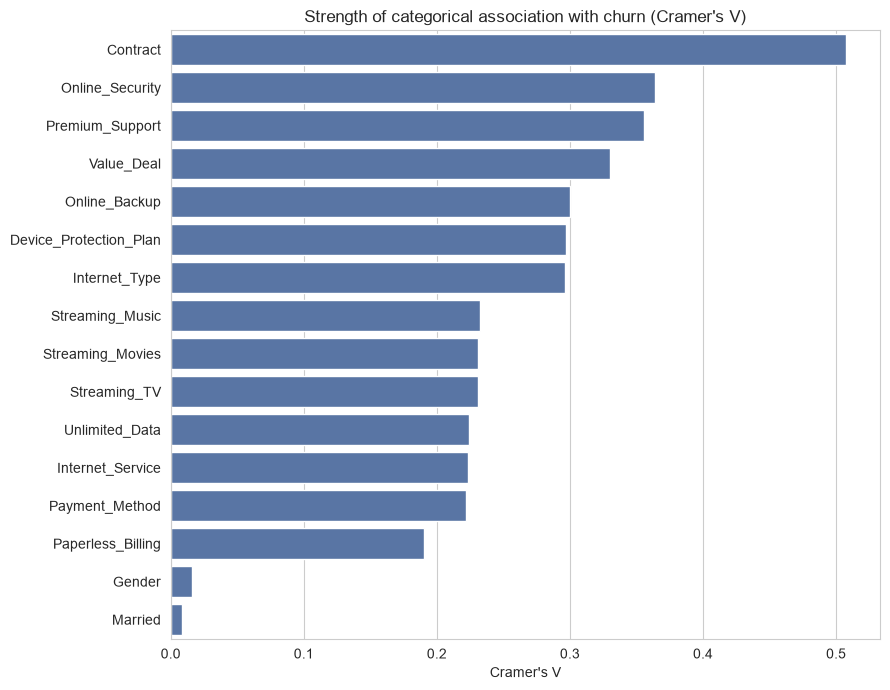

In [3]:
plt.figure(figsize=(9, 7))
sns.barplot(data=chi2_df, x="cramers_v", y="variable", color="#4C72B0")
plt.title("Strength of categorical association with churn (Cramer's V)")
plt.xlabel("Cramer's V")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Numeric variables vs churn (Mann-Whitney U)

Mann-Whitney U compares distributions between `Churned` and `Stayed` without assuming normality. It's used as statistical validation complementary to the EDA.

In [4]:
numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months", "Monthly_Charge",
    "Total_Charges", "Total_Refunds", "Total_Extra_Data_Charges",
    "Total_Long_Distance_Charges", "Total_Revenue",
]

churned = df_model[df_model[TARGET_COL] == "Churned"]
stayed = df_model[df_model[TARGET_COL] == "Stayed"]

mw_results = []
for col in numeric_cols:
    stat, p_value = mannwhitneyu(churned[col], stayed[col])
    mw_results.append(
        {
            "variable": col,
            "median Churned": churned[col].median(),
            "median Stayed": stayed[col].median(),
            "p_value": p_value,
            "significant (p<0.05)": p_value < 0.05,
        }
    )

pd.DataFrame(mw_results).sort_values("p_value").reset_index(drop=True)

,variable,median Churned,median Stayed,p_value,significant (p<0.05)
0,Total_Revenue,913.39,2966.95,2.258519e-158,True
1,Total_Charges,706.85,1941.50,8.944837e-129,True
2,Total_Long_Distance_Charges,139.80,667.40,1.644270e-124,True
3,Monthly_Charge,79.60,66.70,4.364209e-34,True
4,Age,50.00,45.00,1.554528e-15,True
5,Total_Refunds,0.00,0.00,3.860782e-05,True
6,Total_Extra_Data_Charges,0.00,0.00,1.023921e-04,True
7,Tenure_in_Months,17.00,16.00,5.172970e-01,False
8,Number_of_Referrals,7.00,8.00,5.408257e-01,False


## Finding: low `Total_Charges` doesn't mean real risk for `Joined` customers

`Joined` customers have low accumulated totals by construction: they just signed up. If the model uses accumulated totals like `Total_Charges` or `Total_Revenue`, it can confuse low tenure with churn risk.

In [5]:
umbral_bajo = df_joined["Total_Charges"].quantile(0.95)
print(f"95th percentile of Total_Charges in Joined customers: {umbral_bajo:.2f}")

grupo_bajo = df_model[df_model["Total_Charges"] <= umbral_bajo]
churn_rate_grupo_bajo = (grupo_bajo[TARGET_COL] == "Churned").mean()
churn_rate_general = (df_model[TARGET_COL] == "Churned").mean()

print(f"% of df_model with Total_Charges <= {umbral_bajo:.2f}: {(df_model['Total_Charges'] <= umbral_bajo).mean():.1%}")
print(f"Churn rate in that low group: {churn_rate_grupo_bajo:.1%}")
print(f"Overall churn rate:           {churn_rate_general:.1%}")

95th percentile of Total_Charges in Joined customers: 233.42
% of df_model with Total_Charges <= 233.42: 13.1%
Churn rate in that low group: 71.1%
Overall churn rate:           28.9%


## Conclusion

- The categorical variables with the strongest practical strength include `Contract` and `Value_Deal`.
- `Monthly_Charge` contributes a useful numeric signal after filtering out negative values.
- Accumulated totals since sign-up (`Total_Charges`, `Total_Revenue`, `Total_Refunds`, `Total_Extra_Data_Charges`, `Total_Long_Distance_Charges`) are excluded from training to avoid leakage and inflated predictions for new customers.